# 03 - Evaluation (FD001 Test Set)

**Purpose:** Evaluate trained LSTM quality and verify predictions vary with input patterns.

**Inputs:** `model/best_model.pth`, processed test arrays, test trajectories

**Outputs:** RMSE/MAE/R2 metrics + scatter and per-engine trend plots.

In [3]:
import pickle
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from model.lstm_model import LSTMRULModel

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_PATH = PROJECT_ROOT / "model" / "best_model.pth"
DEVICE = torch.device("cpu")
RUL_CAP = 125.0

In [4]:
X_test = np.load(PROCESSED_DIR / "X_test_last.npy")
y_test = np.load(PROCESSED_DIR / "y_test_last.npy")
test_unit_ids = np.load(PROCESSED_DIR / "test_unit_ids.npy")

with open(PROCESSED_DIR / "test_engine_trajectories.pkl", "rb") as fp:
    test_trajectories = pickle.load(fp)

model = LSTMRULModel(input_size=14, hidden_size=128, num_layers=2, dropout=0.2).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

with torch.no_grad():
    test_preds = model(torch.tensor(X_test, dtype=torch.float32, device=DEVICE)).cpu().numpy() * RUL_CAP

rmse = float(np.sqrt(mean_squared_error(y_test, test_preds)))
mae = float(mean_absolute_error(y_test, test_preds))
r2 = float(r2_score(y_test, test_preds))

print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")
print(f"Prediction STD: {float(np.std(test_preds)):.4f}")

RMSE: 14.6344
MAE : 10.6464
R2  : 0.8760
Prediction STD: 40.3709


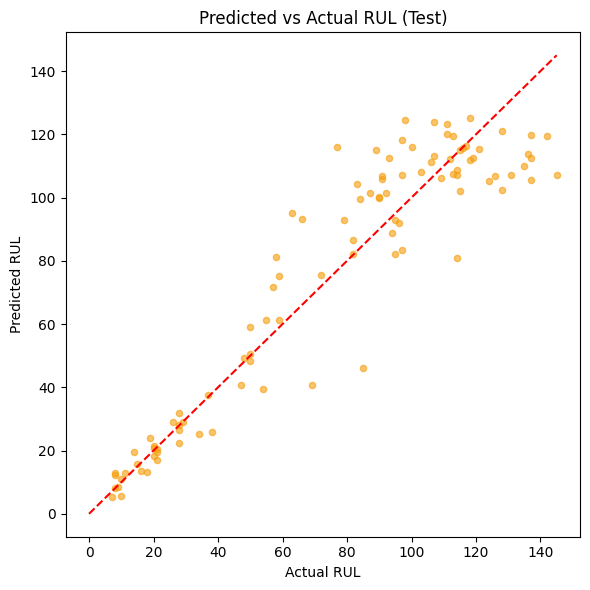

In [5]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_preds, alpha=0.6, s=20, color="#f59e0b")
lims = [0, max(float(y_test.max()), float(test_preds.max()))]
plt.plot(lims, lims, color="red", linestyle="--", linewidth=1.5)
plt.title("Predicted vs Actual RUL (Test)")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.tight_layout()
plt.show()

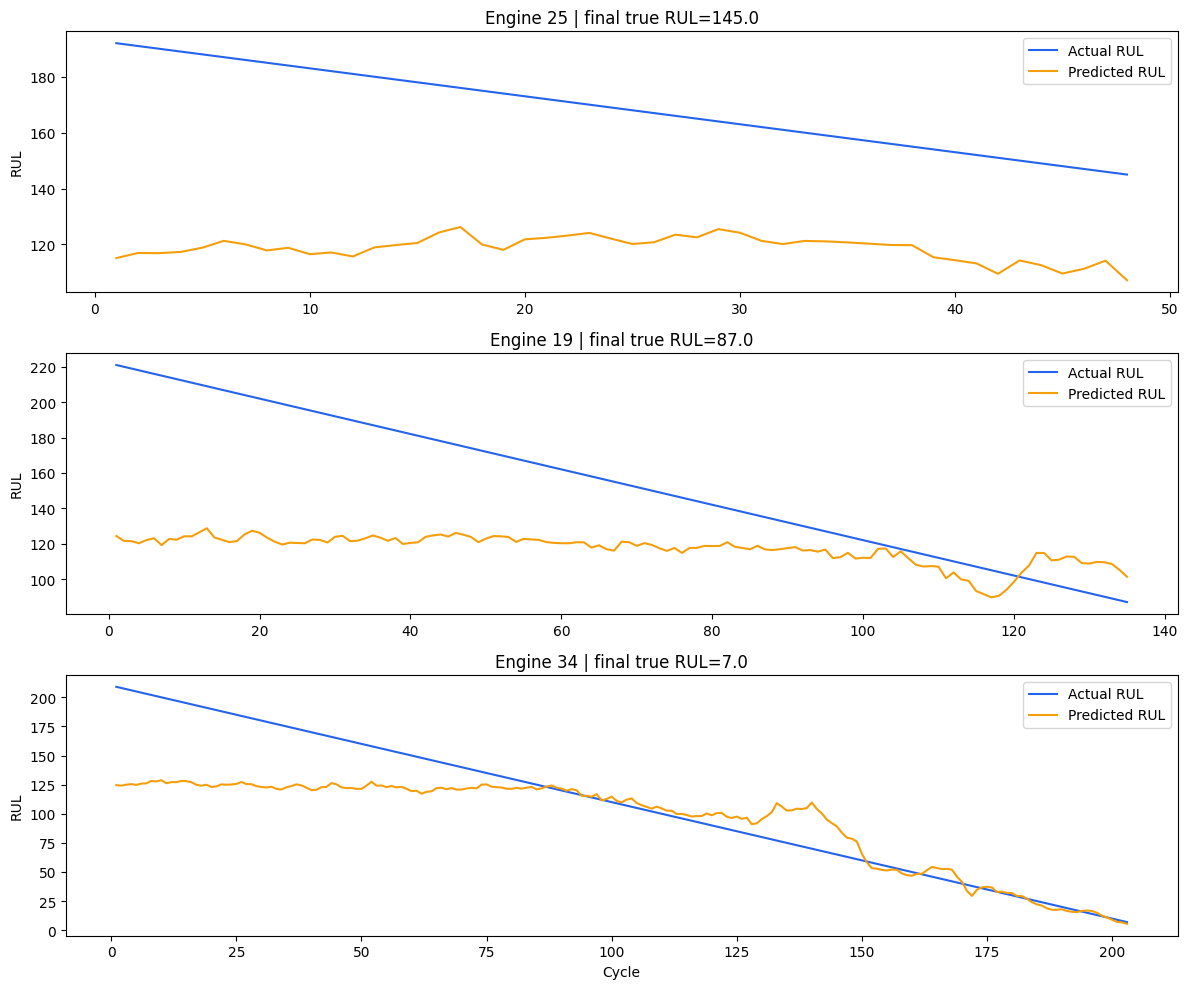

In [6]:
# Plot one healthy, one mid-life, and one near-failure engine.
final_rul_pairs = sorted(
    [(uid, test_trajectories[int(uid)]["final_rul"]) for uid in test_unit_ids],
    key=lambda x: x[1],
)
near_failure_engine = int(final_rul_pairs[0][0])
healthy_engine = int(final_rul_pairs[-1][0])
mid_engine = int(final_rul_pairs[len(final_rul_pairs) // 2][0])
selected = [healthy_engine, mid_engine, near_failure_engine]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

for ax, engine_id in zip(axes, selected):
    payload = test_trajectories[engine_id]
    seqs = torch.tensor(payload["sequences"], dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        preds_over_time = model(seqs).cpu().numpy() * RUL_CAP

    cycles = np.array(payload["cycles"])
    actual = np.array(payload["actual_rul"])

    ax.plot(cycles, actual, label="Actual RUL", color="#2563eb", linewidth=1.5)
    ax.plot(cycles, preds_over_time, label="Predicted RUL", color="#f59e0b", linewidth=1.5)
    ax.set_title(f"Engine {engine_id} | final true RUL={payload['final_rul']:.1f}")
    ax.set_ylabel("RUL")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Cycle")
plt.tight_layout()
plt.show()